# 00 - Pre-analysis Quality Control

**Run this notebook first**, before the per-tissue analysis notebooks.

It loads your Plasmidsaurus expression matrix and metadata, computes per-sample QC metrics, and produces a report you can review to decide whether any samples should be excluded from downstream analysis.

### What it checks

1. **Library size** — total reads per sample (Plasmidsaurus aims for ~10M deduplicated)
2. **Gene detection** — how many genes pass a minimum count threshold
3. **Biotype composition** — % of reads in protein-coding, mitochondrial, ribosomal RNA
4. **Single-gene dominance** — flags samples where one gene hogs >10% of reads
5. **Mapping statistics** — % uniquely mapped, multi-mapped, unmapped (from Plasmidsaurus's `mapping-stats-reads.csv`)
6. **Sex marker expression** — verifies your declared `Sex` matches actual Xist / Y-gene expression (catches mislabeling)
7. **Sample-to-sample correlation** — replicates within a group should correlate ≥ 0.9

### Output

- `qc/qc_metrics.csv` — per-sample metrics with pass/fail flags
- `qc/qc_sex_check.csv` — sex marker expression and consistency
- `qc/qc_mapping_stats.csv` — formatted mapping statistics
- Plots displayed inline (and saved if you choose)

After reviewing, **note the sample IDs you want to exclude** and add them to `DROP_SAMPLES` in each tissue notebook's config cell.

---

### Note on Plasmidsaurus 3' tag-seq

Some "standard" RNA-seq QC thresholds need adjustment for 3' tag-seq because:

- Most reads pile up in the last ~400bp of each transcript (3' UTR region)
- Read coverage is *intentionally* uneven across the transcript
- Multi-mapping rates can be higher than for full-transcript RNA-seq
- Library complexity is bounded by the number of unique transcripts, not bases

The default thresholds in this notebook are reasonable for 3' tag-seq. Be skeptical of generic RNA-seq QC guidelines that aren't 3'-aware.

## 1. Setup

In [1]:
library("DESeq2")
library(tidyverse)
library(pheatmap)
library("RColorBrewer")
library(scales)

# Source the reusable helper functions
source("~/project_pi_epm38/jfd42/pipelines/plasmidsaurus_bulkrnaseq/pipeline_utils.R")
source("~/project_pi_epm38/jfd42/pipelines/plasmidsaurus_bulkrnaseq/load_featurecounts.R")


# patchwork is optional but nice for combined plots; install if missing
if (!requireNamespace("patchwork", quietly = TRUE)) {
  cat("Note: patchwork not installed; QC plots will be shown individually.\n")
  cat("To install: install.packages('patchwork') or add r-patchwork to your conda env.\n")
}

options(repr.plot.width = 12, repr.plot.height = 10)
Sys.time()

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: GenomicRanges

Loading required package: GenomeInfoDb

Loa

[1] "2026-07-11 09:31:14 EDT"

## 2. Configuration

In [2]:
# ----- File paths -----
COUNTS_MATRIX     <- "rawcounts_GRCm39.txt"
GTF_PATH <- "/nfs/roberts/project/pi_epm38/jfd42/GENCODE/GRCm39/gencode.vM39.primary_assembly.annotation.gtf"
METADATA_CSV      <- "metadata.csv"
MAPPING_STATS     <- NULL  # set to NULL if not available
QC_OUTPUT_DIR     <- "post_alignment_qc"

# ----- QC thresholds -----
# These are reasonable defaults for Plasmidsaurus 3' tag-seq.
# Adjust as needed for your data.
QC_THRESHOLDS <- list(
  min_library            = 5e6,    # 5M total reads
  min_genes              = 12000,  # at least 12k genes detected at >= 10 reads
  min_pct_protein_coding = 60,     # >=60% reads in protein-coding genes
  max_pct_mt             = 15,     # <=15% reads in mitochondrial genes
  max_top_gene_pct       = 15      # no single gene takes more than 15% of reads
)

dir.create(QC_OUTPUT_DIR, recursive = TRUE, showWarnings = FALSE)
cat("QC output will be written to:", QC_OUTPUT_DIR, "\n")

QC output will be written to: post_alignment_qc 


## 3. Load data

In [6]:
# Load expression matrix
ps <- load_featurecounts(counts_path = COUNTS_MATRIX, gtf_path = GTF_PATH)
counts    <- ps$counts
gene_info <- ps$gene_info

# Load metadata
metadata <- read.csv(METADATA_CSV, row.names = "sample_id", check.names = FALSE)
metadata$sample_id <- as.character(metadata$sample_id)
rownames(metadata) <- metadata$sample_id

# Sanity: do the IDs match?
in_both <- intersect(colnames(counts), rownames(metadata))
cat("\nSample matching check:\n")
cat("  Counts columns:    ", ncol(counts), "\n")
cat("  Metadata rows:     ", nrow(metadata), "\n")
cat("  Matched sample IDs:", length(in_both), "\n")

if (length(in_both) < ncol(counts)) {
  cat("  In counts but NOT in metadata:",
      paste(setdiff(colnames(counts), rownames(metadata)), collapse = ", "), "\n")
}
if (length(in_both) < nrow(metadata)) {
  cat("  In metadata but NOT in counts:",
      paste(setdiff(rownames(metadata), colnames(counts)), collapse = ", "), "\n")
}

Reading rawcounts_GRCm39.txt ...
Parsing gene_type from GTF for biotype annotation...
  Biotype assigned for 78045 of 78045 genes
  Genes:   78045 
  Samples: 15 
  Sample names: CTRL_F1, CTRL_F2, CTRL_F4, CTRL_M1, CTRL_M2, CTRL_M3, F1C1, F1C2, F2C2, FAmp_0, FAmp_LL, FAmp_RR, M1C1, M1C2, M1C3 
  Library size range:  2,724,909 to 20,627,481 reads


ERROR: Error in `$<-.data.frame`(`*tmp*`, sample_id, value = character(0)): replacement has 0 rows, data has 15


In [9]:
markers_F <- c("Xist","Tsix"); markers_M <- c("Ddx3y","Uty","Eif2s3y","Kdm5d")
all_markers <- c(markers_F, markers_M)
ids <- gene_info$gene_id[match(all_markers, gene_info$gene_name)]
found <- !is.na(ids)

marker_counts <- counts[ids[found], , drop = FALSE]
rownames(marker_counts) <- all_markers[found]

lib <- colSums(counts)
marker_counts <- sweep(marker_counts, 2, lib / 1e6, "/")

out <- as.data.frame(t(marker_counts))
cat("nrow(out):", nrow(out), "\n")
cat("rownames(out):", rownames(out), "\n")
cat("class of rownames:", class(rownames(out)), "\n")
str(out)

nrow(out): 15 
rownames(out): CTRL_F1 CTRL_F2 CTRL_F4 CTRL_M1 CTRL_M2 CTRL_M3 F1C1 F1C2 F2C2 FAmp_0 FAmp_LL FAmp_RR M1C1 M1C2 M1C3 
class of rownames: character 
'data.frame':	15 obs. of  6 variables:
 $ Xist   : num  536.2 776.4 521 22.7 18.5 ...
 $ Tsix   : num  423.1 597.1 401.1 12.5 19.3 ...
 $ Ddx3y  : num  0.734 0.0896 0.0496 44.7375 81.313 ...
 $ Uty    : num  0.367 0 0.149 18.092 29.765 ...
 $ Eif2s3y: num  1.468 1.433 0.248 30.922 50.384 ...
 $ Kdm5d  : num  0 0.0896 0.0992 12.8291 15.797 ...


## 4. Run the full QC report

In [10]:
# ---- QC metrics + outlier flagging ----
metrics <- compute_qc_metrics(counts, gene_info, metadata)
flagged <- flag_qc_outliers(
  metrics,
  min_library            = 5e6,
  min_genes              = 12000,
  min_pct_protein_coding = 60,
  max_pct_mt             = 15,
  max_top_gene_pct       = 15
)

# ---- Sex check, done inline (bypasses the broken helper) ----
sex_markers <- c("Xist","Ddx3y","Uty","Eif2s3y","Kdm5d")
cpm <- sweep(counts[sex_markers, ], 2, as.numeric(colSums(counts))/1e6, "/")
sex_tbl <- data.frame(
  sample     = colnames(counts),
  declared   = metadata[colnames(counts), "Sex"],
  Xist       = round(cpm["Xist", ], 1),
  Y_mean     = round(colMeans(cpm[c("Ddx3y","Uty","Eif2s3y","Kdm5d"), ]), 1)
)
sex_tbl$predicted   <- ifelse(sex_tbl$Xist > sex_tbl$Y_mean, "F", "M")
sex_tbl$consistent  <- sex_tbl$declared == sex_tbl$predicted

# ---- keep a `qc` object so later cells that reference it still work ----
qc <- list(metrics = flagged,
           sex_check = sex_tbl,
           flagged_samples = flagged$sample_id[!flagged$pass_qc])

cat("\n===== SEX CHECK =====\n")
print(sex_tbl)
cat("\n===== FLAGGED SAMPLES =====\n")
print(flagged[!flagged$pass_qc, c("sample_id","library_size","pass_qc")])

Thresholds applied:
  library_size         >= 5e+06 
  n_genes_detected_10  >= 12000 
  pct_protein_coding   >= 60 %
  pct_mt               <= 15 %
  top_gene_pct         <= 15 %

Samples flagged for review (failing one or more checks):
   CTRL_F1 : low library (2,724,909); high % mt (19.4%) 
   CTRL_M1 : low library (3,039,952) 

Note: flagging is advisory. Review the QC plots before deciding.

===== SEX CHECK =====
         sample declared  Xist Y_mean predicted consistent
CTRL_F1 CTRL_F1        F 536.2    0.6         F       TRUE
CTRL_F2 CTRL_F2        F 776.4    0.4         F       TRUE
CTRL_F4 CTRL_F4        F 521.0    0.1         F       TRUE
CTRL_M1 CTRL_M1        M  22.7   26.6         M       TRUE
CTRL_M2 CTRL_M2        M  18.5   44.3         M       TRUE
CTRL_M3 CTRL_M3        M  11.1   46.0         M       TRUE
F1C1       F1C1        F 510.6    0.2         F       TRUE
F1C2       F1C2        F 505.2    0.2         F       TRUE
F2C2       F2C2        F 518.3    0.4         F 

## 5. Inspect the metrics table

In [11]:
# Print the full metrics table for inspection
options(repr.matrix.max.cols = 30)
qc$metrics %>%
  dplyr::select(sample_id, Sex, Exposure, Tissue,
                library_size, n_genes_detected_10,
                pct_protein_coding, pct_mt, top_gene_pct,
                pass_qc) %>%
  dplyr::arrange(library_size)

sample_id,Sex,Exposure,Tissue,library_size,n_genes_detected_10,pct_protein_coding,pct_mt,top_gene_pct,pass_qc
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
CTRL_F1,F,CTRL,LUNG,2724909,15564,71.83319,19.446521,4.576777,FALSE
CTRL_M1,M,CTRL,LUNG,3039952,16511,62.18572,13.584524,12.459276,FALSE
CTRL_M2,M,CTRL,LUNG,6013796,18670,77.78368,12.743931,5.039779,TRUE
CTRL_M3,M,CTRL,LUNG,10518153,20779,80.18856,10.951638,2.020583,TRUE
CTRL_F2,F,CTRL,LUNG,11166891,22020,82.34730,6.551734,2.412032,TRUE
M1C2,M,Crystalline,LUNG,12086215,20330,83.53637,5.337304,1.917689,TRUE
FAmp_0,F,Amorphous,LUNG,15690392,21394,83.19743,4.816432,1.699365,TRUE
M1C1,M,Crystalline,LUNG,16496539,21572,82.03732,5.181105,2.044841,TRUE
F2C2,F,Crystalline,LUNG,17557592,22847,81.65655,4.982825,1.279156,TRUE


## 6. Visualize QC metrics

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Genes detected (≥ 10 reads)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Genes detected (≥ 10 reads)' in 'mbcsToSbcs': dot substituted for <89>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Genes detected (≥ 10 reads)' in 'mbcsToSbcs': dot substituted for <a5>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Genes detected (≥ 10 reads)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Genes detected (≥ 10 reads)' in 'mbcsToSbcs': dot substituted for <89>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure

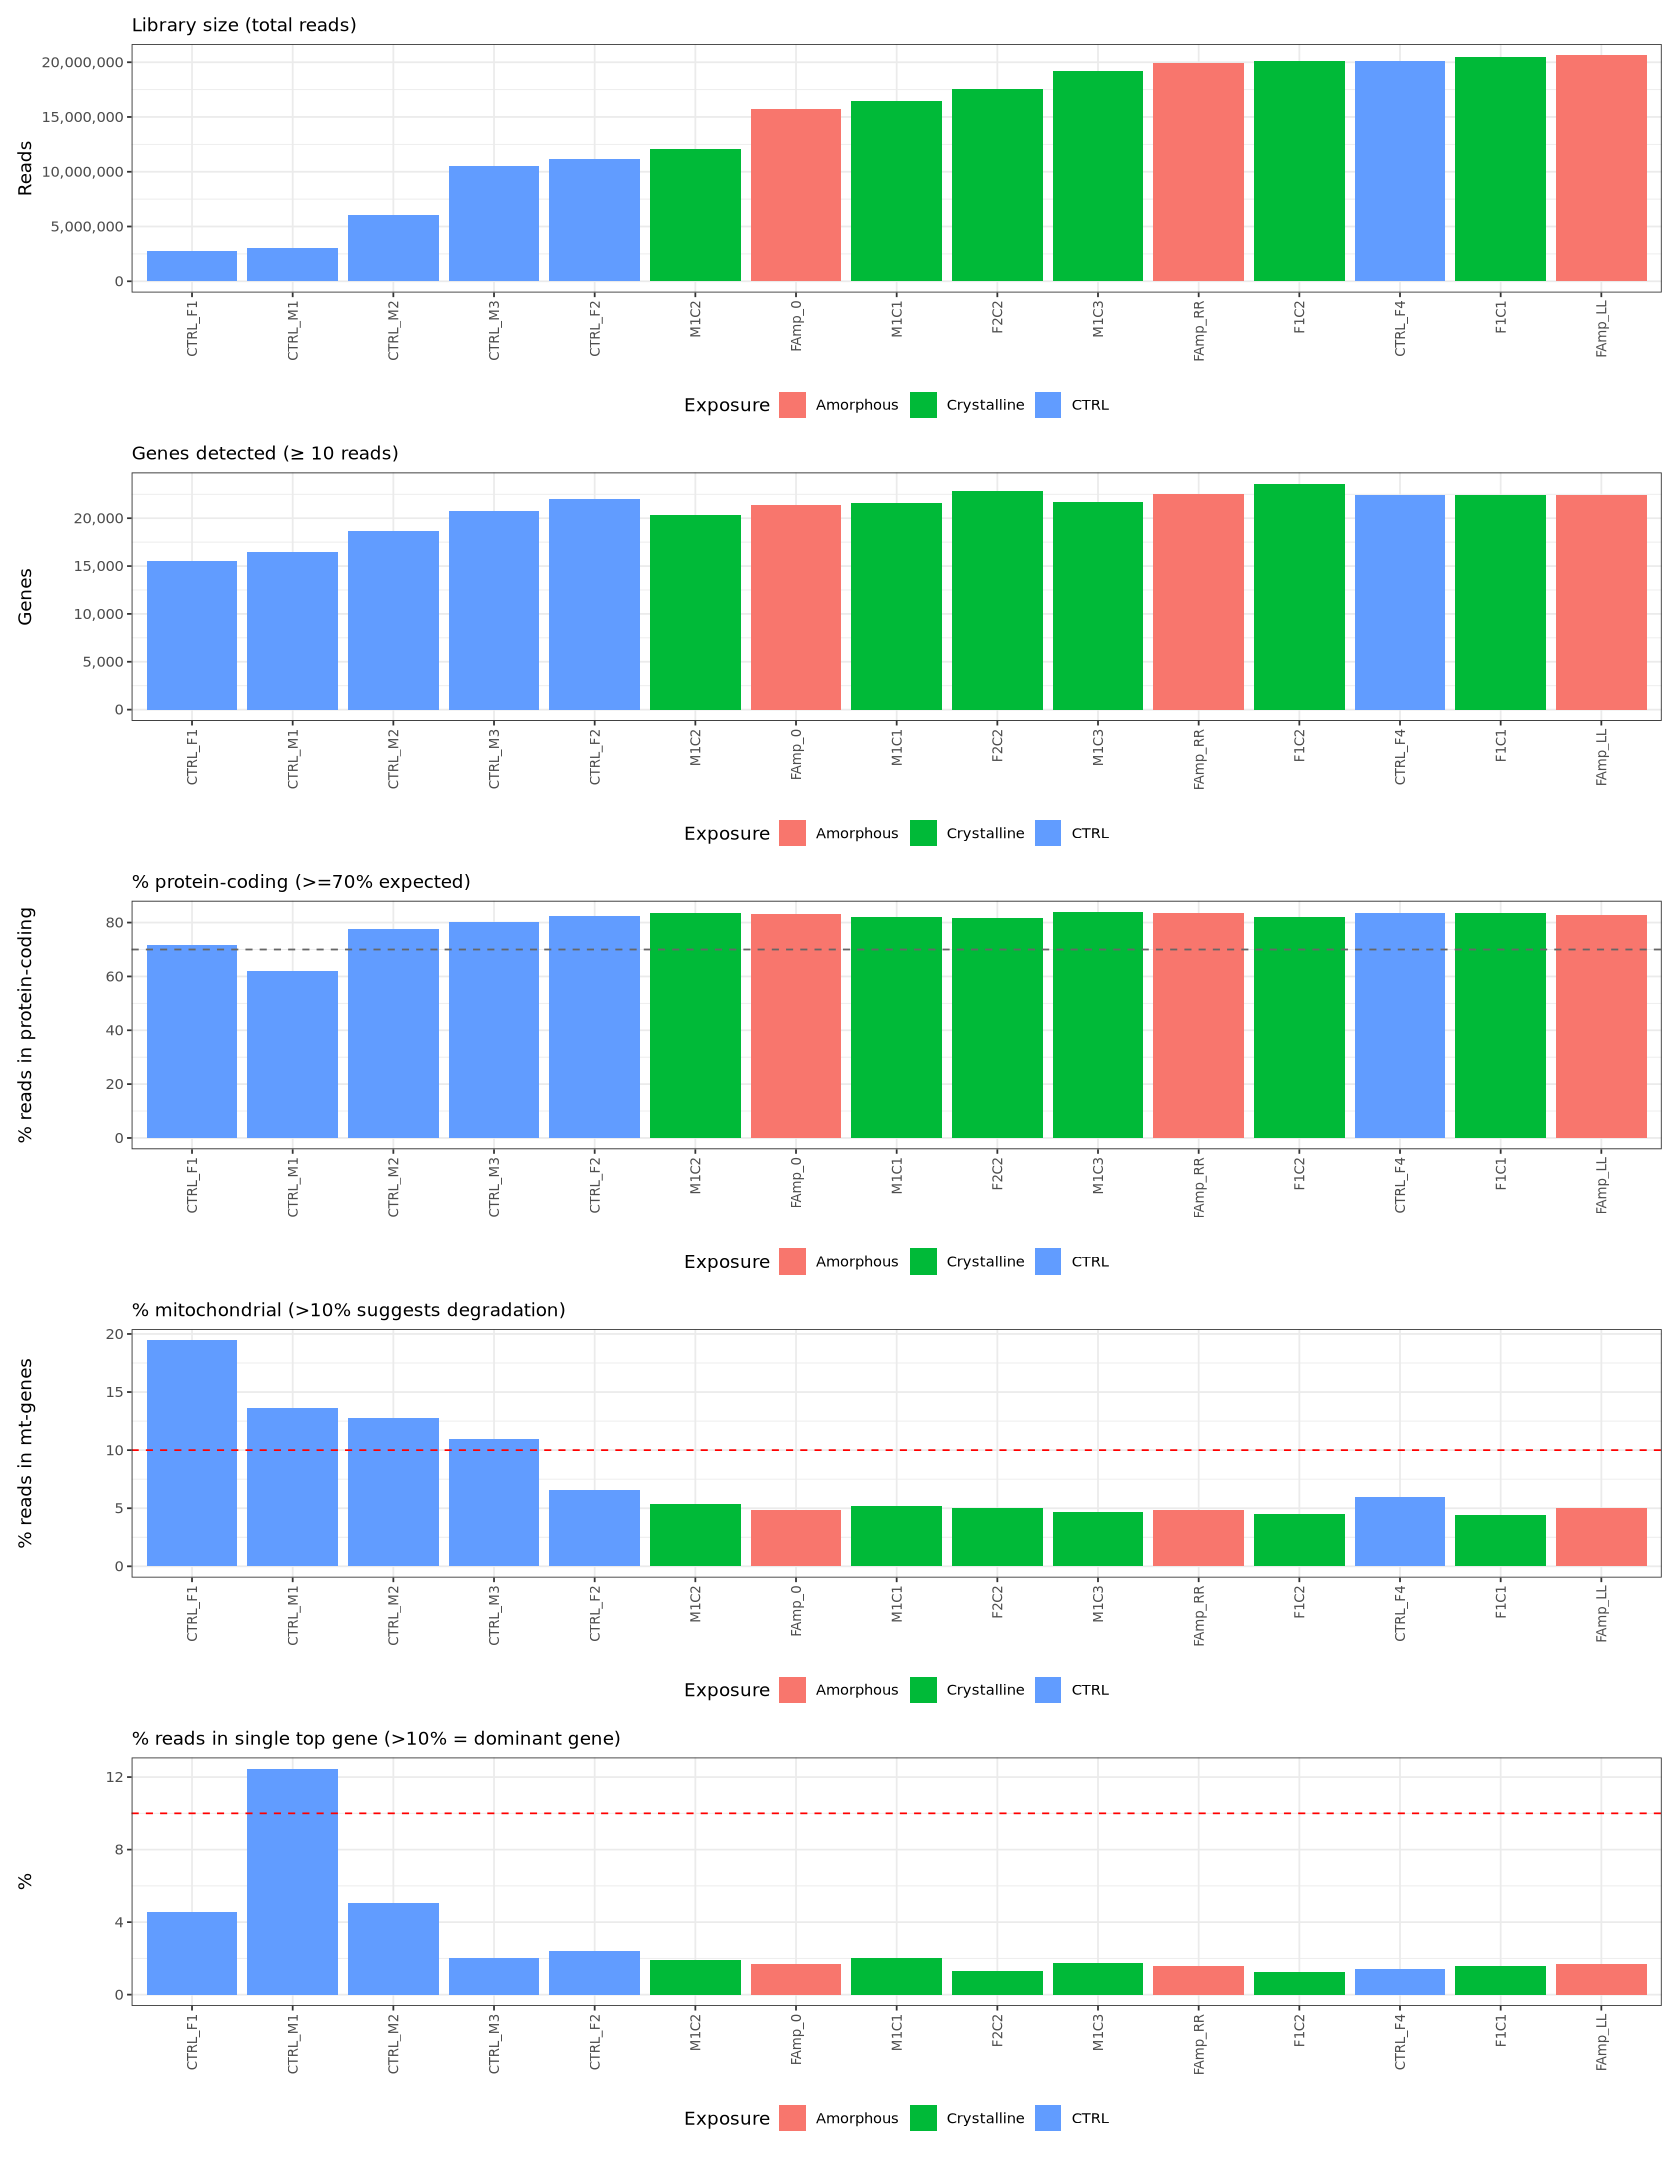

In [12]:
# Multi-panel QC summary plot
options(repr.plot.width = 14, repr.plot.height = 18)
p_summary <- plot_qc_summary(qc$metrics,
                              mapping_stats = qc$mapping_stats,
                              color_by = "Exposure")
p_summary

# Save to PDF
ggplot2::ggsave(file.path(QC_OUTPUT_DIR, "qc_summary.pdf"),
                p_summary, width = 14, height = 18, limitsize = FALSE)

### Reading these plots

- **Library size**: bars are sorted from smallest to largest. Look for samples that fall well below the rest of their group.
- **Genes detected (>=10 reads)**: should track library size; a sample with high library but low detection has unusual count distribution (a few highly-expressed genes hogging reads, common with degraded samples).
- **% protein-coding**: typically 70-90% for healthy mRNA libraries. Lower may indicate degradation or contamination.
- **% mitochondrial**: typically <5%. Elevated mt% (>10%) is a classic degradation marker — when cells/tissues are stressed or RNA is partially degraded, mtRNA (which is more stable) becomes proportionally enriched.
- **% reads in top gene**: a single dominant gene means a small set of transcripts is consuming most reads, which can dominate downstream analysis. Common culprits: rRNA contamination (rRNA genes), hemoglobin in blood-contaminated samples (Hbb-bs, Hbb-bt), albumin in serum-contaminated samples.
- **% uniquely mapped / unmapped**: should be >70% / <10% respectively. Lower mapping suggests adapter contamination, rRNA, or sequencing issues.

**The dashed lines in each plot show conventional thresholds** — but they are guidelines, not strict cutoffs. Treat the plots as a starting point for investigating outliers, not as automatic exclusion criteria.

## 7. Sex marker check

In [13]:
# Show the sex check table
if (!is.null(qc$sex_check)) {
  cat("Sex marker expression (CPM-normalized) and consistency:\n\n")
  print(qc$sex_check)

  # Highlight any mismatches
  mm <- qc$sex_check %>% dplyr::filter(!sex_consistent)
  if (nrow(mm) > 0) {
    cat("\n⚠️ Sex marker mismatches:\n")
    print(mm)
    cat("\nThese samples express markers inconsistent with the declared Sex.\n")
    cat("Investigate before proceeding - this is often a sample swap.\n")
  } else {
    cat("\n✓ All samples are consistent with declared sex.\n")
  }
}

Sex marker expression (CPM-normalized) and consistency:

         sample declared  Xist Y_mean predicted consistent
CTRL_F1 CTRL_F1        F 536.2    0.6         F       TRUE
CTRL_F2 CTRL_F2        F 776.4    0.4         F       TRUE
CTRL_F4 CTRL_F4        F 521.0    0.1         F       TRUE
CTRL_M1 CTRL_M1        M  22.7   26.6         M       TRUE
CTRL_M2 CTRL_M2        M  18.5   44.3         M       TRUE
CTRL_M3 CTRL_M3        M  11.1   46.0         M       TRUE
F1C1       F1C1        F 510.6    0.2         F       TRUE
F1C2       F1C2        F 505.2    0.2         F       TRUE
F2C2       F2C2        F 518.3    0.4         F       TRUE
FAmp_0   FAmp_0        F 479.0    0.2         F       TRUE
FAmp_LL FAmp_LL        F 501.8    0.1         F       TRUE
FAmp_RR FAmp_RR        F 504.7    0.0         F       TRUE
M1C1       M1C1        M   5.2   43.9         M       TRUE
M1C2       M1C2        M   7.0   42.4         M       TRUE
M1C3       M1C3        M   5.6   37.6         M       TRUE

ERROR: [1m[33mError[39m in `dplyr::filter()`:[22m
[1m[22m[36mℹ[39m In argument: `!sex_consistent`.
[1mCaused by error:[22m
[33m![39m object 'sex_consistent' not found


In [14]:
# Visualize sex marker expression
if (!is.null(qc$sex_check)) {
  sex_long <- qc$sex_check %>%
    tidyr::pivot_longer(cols = -c(sample_id, declared_sex,
                                  predicted_sex, sex_consistent),
                        names_to = "marker", values_to = "expression") %>%
    dplyr::mutate(marker_type = ifelse(marker %in% c("Xist", "Tsix"),
                                       "Female (X-linked)", "Male (Y-linked)"))

  options(repr.plot.width = 12, repr.plot.height = 7)
  ggplot(sex_long, aes(x = sample_id, y = expression, fill = marker)) +
    geom_col(position = "dodge") +
    facet_grid(marker_type ~ declared_sex, scales = "free_x", space = "free_x") +
    theme_bw(base_size = 11) +
    theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)) +
    labs(title = "Sex marker expression by declared sex",
         y = "Expression (CPM)",
         subtitle = "Females should have high Xist; males should have high Y-gene expression")

  ggplot2::ggsave(file.path(QC_OUTPUT_DIR, "qc_sex_markers.pdf"),
                  width = 12, height = 7)
}

ERROR: [1m[33mError[39m in `tidyr::pivot_longer()`:[22m
[33m![39m Can't select columns that don't exist.
[31m✖[39m Column `sample_id` doesn't exist.


## 8. Sample-to-sample correlation

Healthy biological replicates from the same group typically correlate >= 0.9 in log2 space. Lower correlation (≤ 0.85) between two samples that should be similar suggests one of them is unusual.

If a sample correlates *better* with samples from a *different* group than its own, that's a strong sample swap signal.

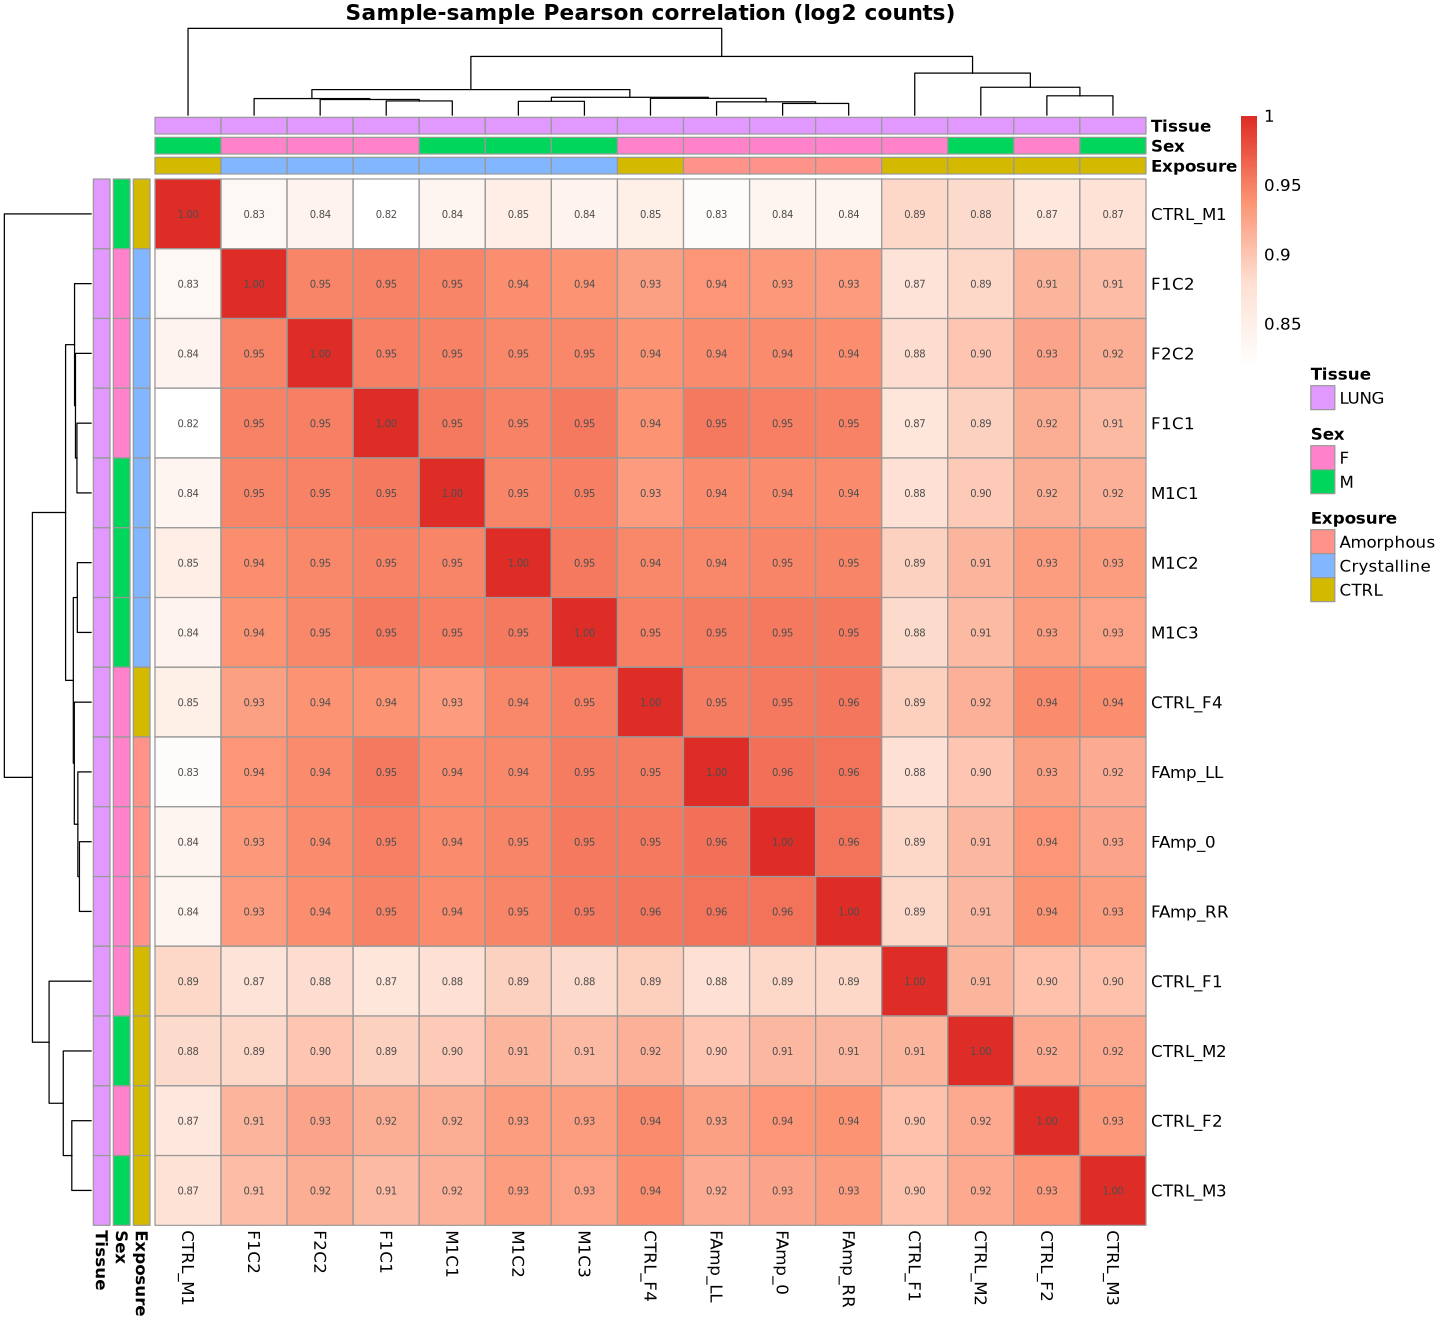

pdf 
  3

Mean correlation within experimental groups:
  F_CTRL_LUNG                   : 0.913 (n = 3 samples)
  M_CTRL_LUNG                   : 0.893 (n = 3 samples)
  F_Crystalline_LUNG            : 0.949 (n = 3 samples)
  F_Amorphous_LUNG              : 0.958 (n = 3 samples)
  M_Crystalline_LUNG            : 0.950 (n = 3 samples)


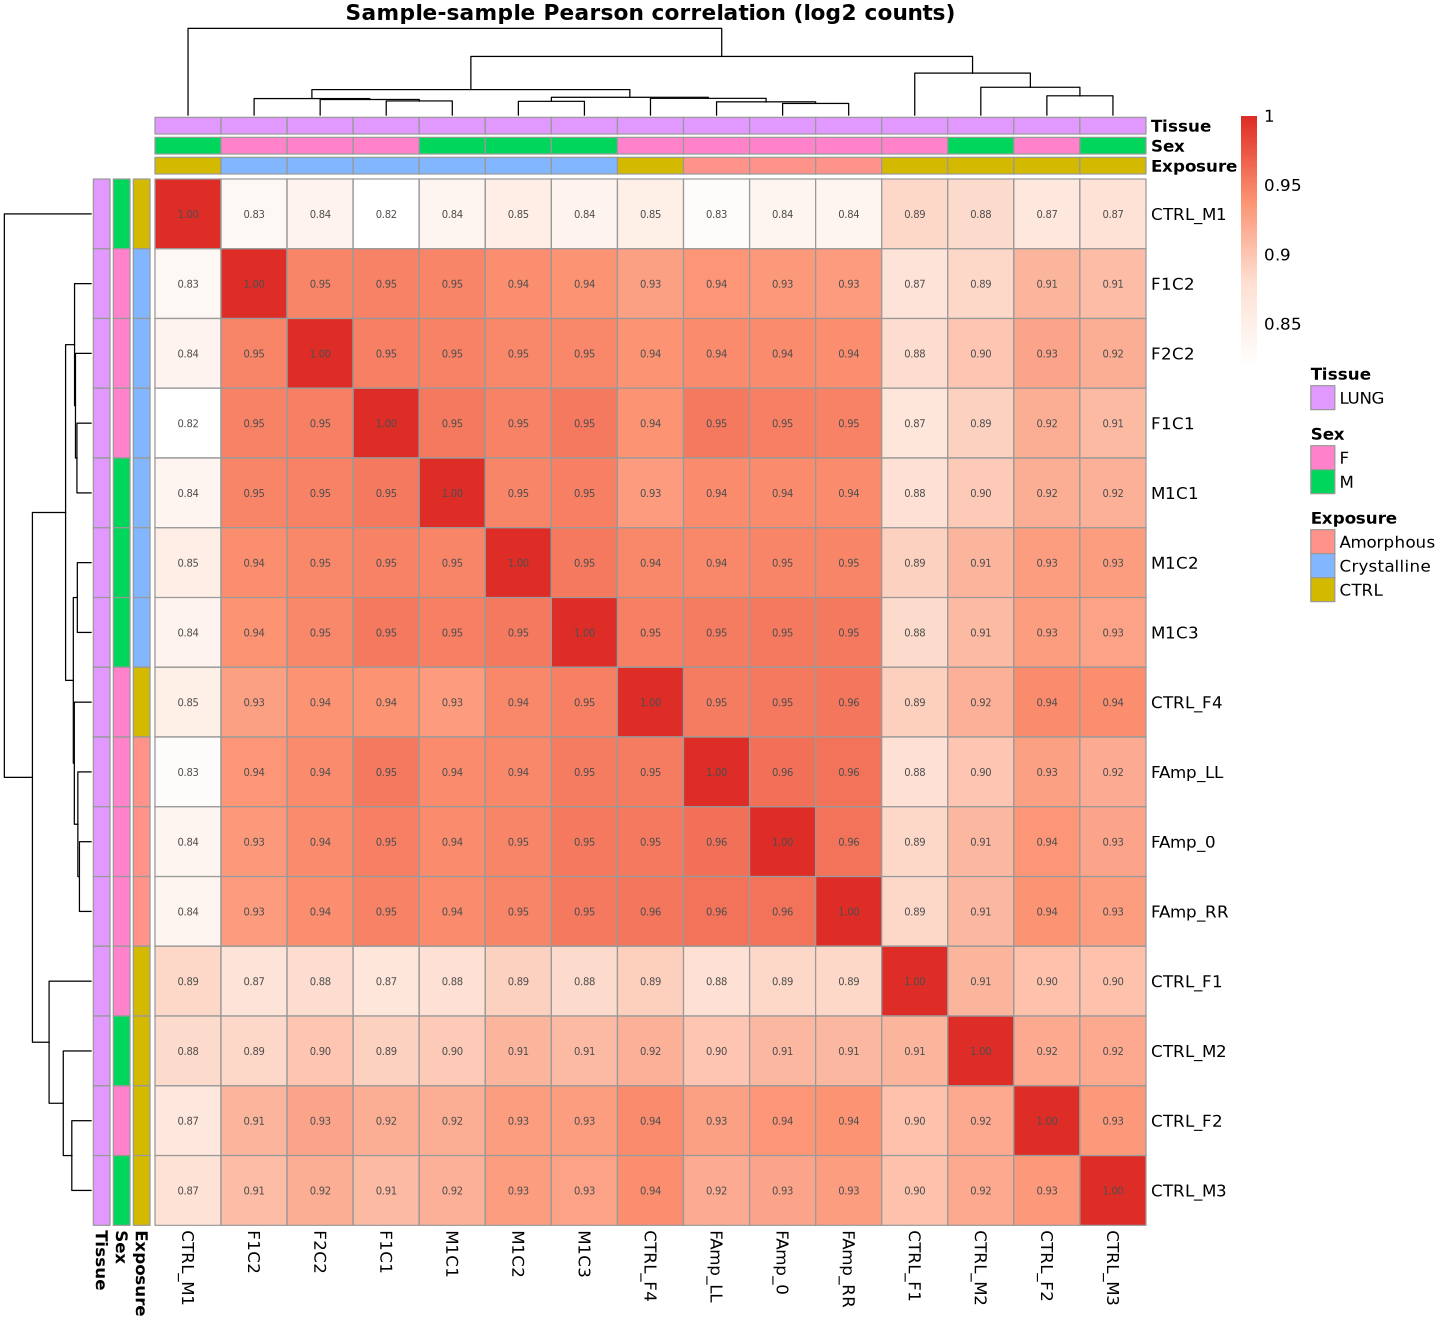

In [15]:
options(repr.plot.width = 12, repr.plot.height = 11)
sc <- plot_sample_correlation(counts, metadata)

pdf(file.path(QC_OUTPUT_DIR, "qc_sample_correlation.pdf"), width = 12, height = 11)
plot_sample_correlation(counts, metadata)
dev.off()

# Print mean within-group vs between-group correlations as a summary
cm <- sc$cor_matrix
md <- metadata[colnames(cm), , drop = FALSE]
group_label <- paste(md$Sex, md$Exposure, md$Tissue, sep = "_")
cat("Mean correlation within experimental groups:\n")
for (g in unique(group_label)) {
  idx <- which(group_label == g)
  if (length(idx) >= 2) {
    sub <- cm[idx, idx]
    diag(sub) <- NA
    cat(sprintf("  %-30s: %.3f (n = %d samples)\n", g, mean(sub, na.rm = TRUE), length(idx)))
  }
}

## 9. Decide on samples to exclude

Based on the analysis above, list the sample IDs you want to drop from downstream analyses. The decision is **yours**, not the pipeline's — these flags are advisory.

**Reasons to drop a sample:**
- Library size dramatically below others in the same group (and the group has enough remaining replicates)
- Sex marker mismatch (likely a sample swap)
- Sample correlates poorly with biological replicates AND well with a different group
- Combination of QC flags (e.g., low library AND low protein-coding AND high mt%)

**Reasons to KEEP a sample even if flagged:**
- It's the only sample in its group (don't drop yourself into n=2)
- It's marginal (e.g., library 4.5M when threshold is 5M) and otherwise looks fine
- Group sizes are already small (n=3); each sample matters

For your reference, the auto-flagged samples are:

In [16]:
qc$flagged_samples
# To drop samples, change the value of the DROP_SAMPLES variable in the following notebook. eg: DROP_SAMPLES <- c("1", "7")
#Note that you must change the following analysis notebooks to drop samples. Uncommenting the below line will not carry over to other notebooks
# DROP_SAMPLES <- c()

[1] "CTRL_F1" "CTRL_M1"

## 10. Session info

In [17]:
sessionInfo()
capture.output(sessionInfo(), file = file.path(QC_OUTPUT_DIR, "sessionInfo.txt"))
Sys.time()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Red Hat Enterprise Linux 9.6 (Plow)

Matrix products: default
BLAS/LAPACK: /nfs/roberts/project/pi_epm38/jfd42/ycrc_conda/envs/20260429bulkrnaseq/lib/libopenblasp-r0.3.32.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8       LC_NUMERIC=C           LC_TIME=C.UTF-8       
 [4] LC_COLLATE=C.UTF-8     LC_MONETARY=C.UTF-8    LC_MESSAGES=C.UTF-8   
 [7] LC_PAPER=C.UTF-8       LC_NAME=C              LC_ADDRESS=C          
[10] LC_TELEPHONE=C         LC_MEASUREMENT=C.UTF-8 LC_IDENTIFICATION=C   

time zone: America/New_York
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] scales_1.4.0                RColorBrewer_1.1-3         
 [3] pheatmap_1.0.13             lubridate_1.9.4            
 [5] forcats_1.0.0               stringr_1.5.2              
 [7] dplyr_1.1.4              

[1] "2026-07-11 09:51:05 EDT"